# Grilla de referencia: letras y números (sin landmarks)

Muestra un ejemplo de imagen por cada letra y por cada número, SIN dibujar
nada de MediaPipe encima -- para ver tal cual qué forma de mano hay que
hacer para cada seña.


In [1]:
import math
from pathlib import Path

import cv2
import matplotlib.pyplot as plt

# Ajustá esta ruta si el notebook no está en la carpeta notebooks/ de la raíz del proyecto
DATASET_DIR = Path("../data/asl_dataset")
COLS_LETTERS = 6
COLS_NUMBERS = 5


In [2]:
def one_example_per_class(dataset_dir: Path, class_filter):
    """
    Recorre las subcarpetas de dataset_dir, se queda solo con las que
    cumplen class_filter(nombre_carpeta), y devuelve un dict
    {nombre_clase: ruta_a_una_imagen_de_ejemplo}.
    """
    examples = {}
    for class_dir in sorted(dataset_dir.iterdir()):
        if not class_dir.is_dir():
            continue
        if not class_filter(class_dir.name):
            continue

        images = [
            p for p in class_dir.iterdir()
            if p.suffix.lower() in {".jpg", ".jpeg", ".png"}
        ]
        if images:
            examples[class_dir.name] = images[0]

    return examples


def plot_grid(examples: dict, title: str, cols: int, numeric_sort: bool = False):
    """
    Dibuja una grilla con la imagen CRUDA de cada clase (sin ningún
    procesamiento de MediaPipe encima).
    """
    labels = sorted(examples.keys(), key=int) if numeric_sort else sorted(examples.keys())
    n = len(labels)
    rows = math.ceil(n / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.2, rows * 2.4))
    axes = axes.flatten() if n > 1 else [axes]

    for ax, label in zip(axes, labels):
        img_bgr = cv2.imread(str(examples[label]))
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        ax.imshow(img_rgb)
        ax.set_title(label, fontsize=14, fontweight="bold")
        ax.axis("off")

    for ax in axes[n:]:
        ax.axis("off")

    fig.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()


## Letras (A-Z)


Letras encontradas: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']


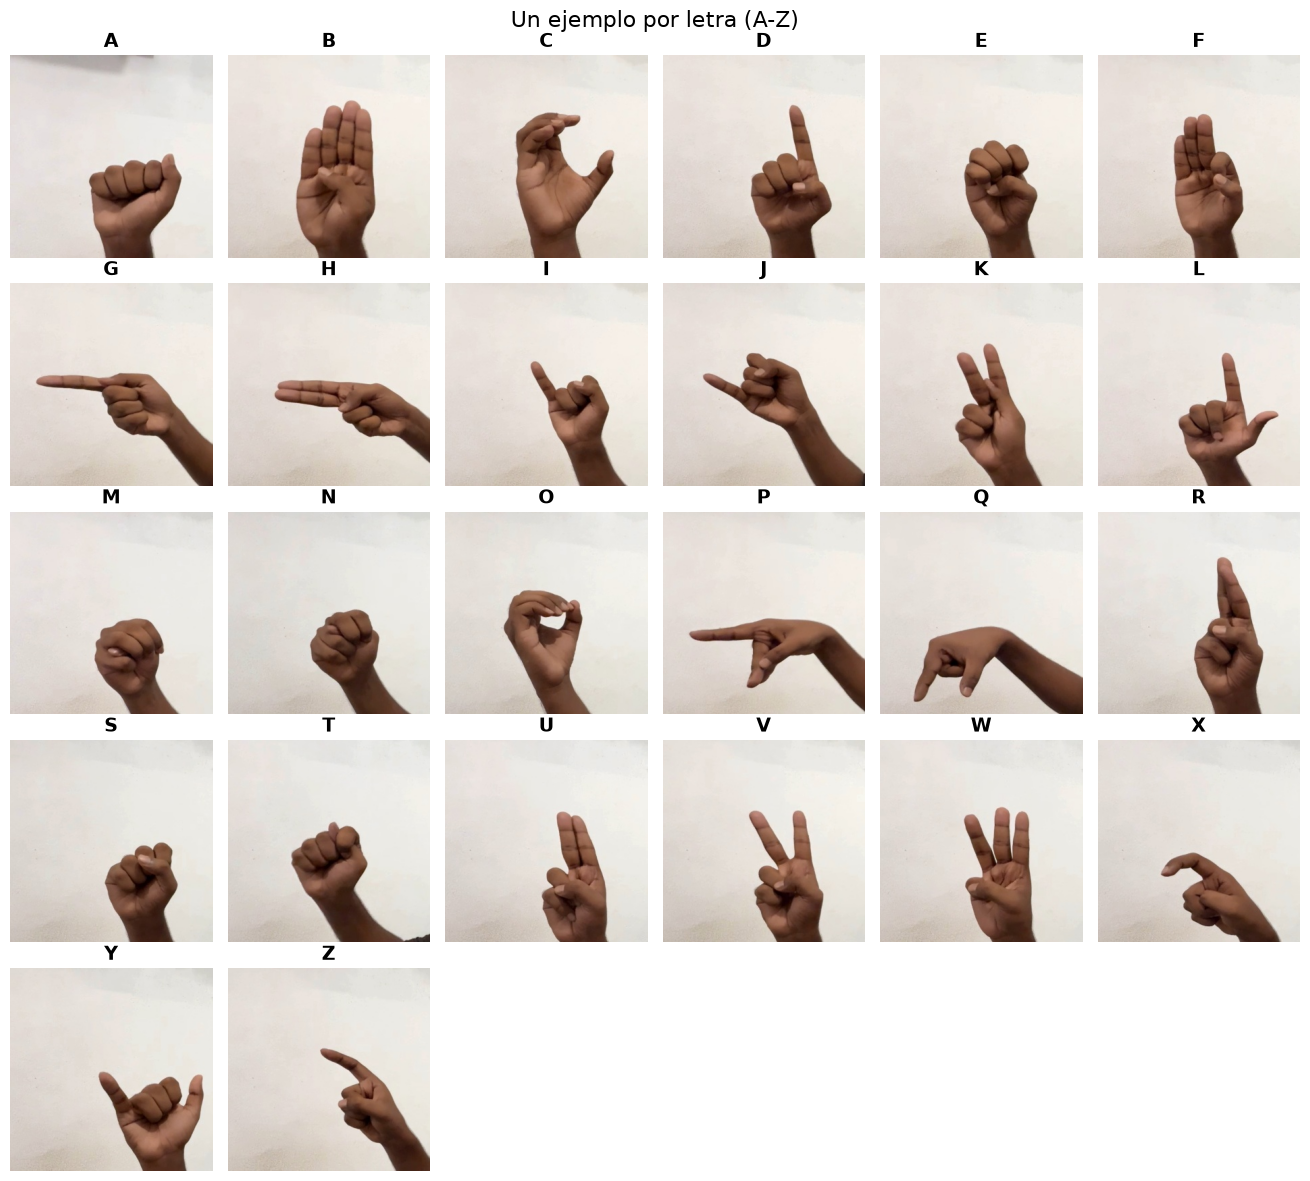

In [3]:
letter_examples = one_example_per_class(
    DATASET_DIR,
    class_filter=lambda name: len(name) == 1 and name.isalpha(),
)

print(f"Letras encontradas: {sorted(letter_examples.keys())}")

plot_grid(
    letter_examples,
    title="Un ejemplo por letra (A-Z)",
    cols=COLS_LETTERS,
)


## Números (0-9, excepto el "0" ya excluido del dataset)


Números encontrados: ['1', '2', '3', '4', '5', '6', '7', '8', '9']


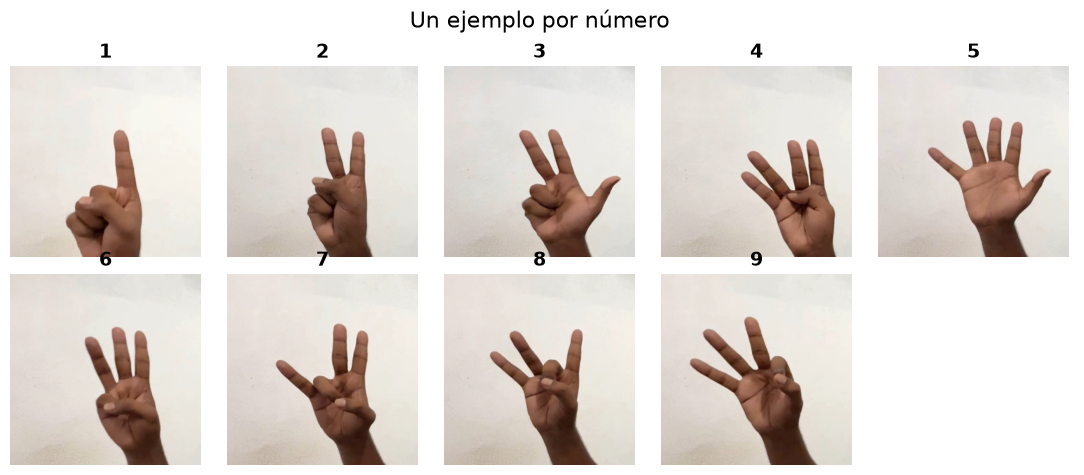

In [4]:
number_examples = one_example_per_class(DATASET_DIR, class_filter=lambda name: name.isdigit())

print(f"Números encontrados: {sorted(number_examples.keys(), key=int)}")

plot_grid(
    number_examples,
    title="Un ejemplo por número",
    cols=COLS_NUMBERS,
    numeric_sort=True,
)
